# Uncertainty Quantification with Last-Layer NUTS

This notebook demonstrates a compact Bayesian workflow for uncertainty quantification in a mechanism-AI coupled SIR model.

We assume the SIR mechanism is known,

$$
\begin{aligned}
S'(t) &= -\beta(t)S(t)I(t),\\
I'(t) &= \beta(t)S(t)I(t)-\gamma I(t),\\
R'(t) &= \gamma I(t),
\end{aligned}
$$

but the time-varying transmission rate $\beta(t)$ is unknown. The goal is to estimate $\beta(t)$ and quantify uncertainty from noisy observations of $I(t)$.

The last-layer idea is simple: keep a feature map $\phi(t)$ fixed and use NUTS only for the final affine layer,

$$
\beta_\theta(t)=\beta_{\min}+\mathrm{softplus}\left(\theta^\top \phi(t)\right).
$$

This is much cheaper than sampling all neural-network parameters, while still giving uncertainty bands for $\beta(t)$ and the SIR trajectories.


## Activate the Julia environment


In [1]:
using Pkg
Pkg.activate(@__DIR__)


  Activating project at `C:\Users\aidishage\Desktop\MyProjects\AIforMathBio\Julia_Tutorial_on_AI4MathBiology`


## Load packages


In [2]:
using Random
using Statistics
using LinearAlgebra
using DifferentialEquations
using SciMLSensitivity
using Turing
using Distributions
using MCMCChains
using StatsPlots

Random.seed!(2026)


TaskLocalRNG()

## Generate synthetic SIR data

For a classroom tutorial, synthetic data is useful because the true $\beta(t)$ is known. Here we observe only the infected compartment and add a small amount of Gaussian noise.


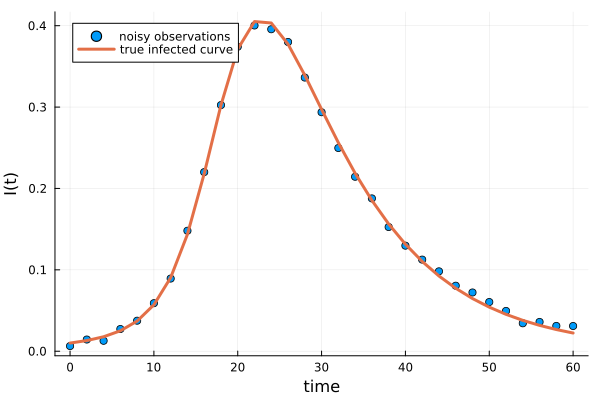

In [3]:
γ_true = 0.10
u0 = [0.99, 0.01, 0.0]
tspan = (0.0, 60.0)
t_obs = collect(0.0:2.0:60.0)
σ_true = 0.004

β_true(t) = 0.22 + 0.16 * exp(-0.5 * ((t - 18.0) / 7.5)^2) + 0.05 * sin(2π * t / 60.0)

function sir_true!(du, u, p, t)
    S, I, R = u
    β = β_true(t)
    γ = p
    du[1] = -β * S * I
    du[2] = β * S * I - γ * I
    du[3] = γ * I
    return nothing
end

prob_true = ODEProblem(sir_true!, u0, tspan, γ_true)
sol_true = solve(prob_true, Tsit5(); saveat=t_obs, abstol=1e-10, reltol=1e-10)
I_clean = Array(sol_true)[2, :]
I_obs = clamp.(I_clean .+ σ_true .* randn(length(t_obs)), 0.0, 1.0)

scatter(t_obs, I_obs; label="noisy observations", xlabel="time", ylabel="I(t)", legend=:topleft)
plot!(t_obs, I_clean; label="true infected curve", linewidth=3)


## Define a fixed feature map and a Bayesian last layer

The feature map below is a small radial-basis expansion of time. In a larger project, these features could come from a pretrained neural network; here we keep them explicit so that the inference problem is easy to inspect.


In [4]:
β_min = 0.02
centers = collect(range(tspan[1], tspan[2]; length=9))
width = 9.0
n_features = length(centers) + 2

softplus_stable(x) = log1p(exp(-abs(x))) + max(x, zero(x))

function features(t)
    x = (t - tspan[1]) / (tspan[2] - tspan[1])
    rbf = exp.(-0.5 .* ((t .- centers) ./ width).^2)
    return vcat(one(t), x, rbf)
end

function β_last_layer(t, θ)
    return β_min + softplus_stable(dot(θ, features(t)))
end

function sir_last_layer!(du, u, θ, t)
    S, I, R = u
    β = β_last_layer(t, θ)
    γ = γ_true
    du[1] = -β * S * I
    du[2] = β * S * I - γ * I
    du[3] = γ * I
    return nothing
end

θ0 = zeros(n_features)
prob_template = ODEProblem(sir_last_layer!, u0, tspan, θ0)

function predict_I(θ; saveat=t_obs)
    prob = remake(prob_template; p=θ)
    sol = solve(
        prob,
        Tsit5();
        saveat=saveat,
        abstol=1e-6,
        reltol=1e-6,
        sensealg=ForwardDiffSensitivity()
    )
    return Array(sol)[2, :]
end


predict_I (generic function with 1 method)

## Build the Turing model

Only the last-layer weights $\theta$ and the observation noise scale $\sigma$ are sampled. The SIR equations remain inside the likelihood.


In [5]:
@model function beta_sir_last_layer_nuts(I_data, t_data)
    θ ~ MvNormal(zeros(n_features), 0.7^2 * I)
    σ ~ truncated(Normal(0.0, 0.02), 1e-4, 0.08)

    pred = predict_I(θ; saveat=t_data)

    for i in eachindex(I_data)
        I_data[i] ~ Normal(pred[i], σ)
    end
end

model = beta_sir_last_layer_nuts(I_obs, t_obs)


DynamicPPL.Model{typeof(beta_sir_last_layer_nuts), (:I_data, :t_data), (), (), Tuple{Vector{Float64}, Vector{Float64}}, Tuple{}, DynamicPPL.DefaultContext, false}(Main.beta_sir_last_layer_nuts, (I_data = [0.006327479501450958, 0.014344566909366847, 0.012798421516718433, 0.02726742308156379, 0.03749452886641756, 0.059002716201581325, 0.08926327822649299, 0.14803414311676483, 0.22007139861693498, 0.3024688996154664  …  0.1125713413491609, 0.09815082270363429, 0.08049105179482734, 0.07216411339062913, 0.06043915664368783, 0.04949025325681044, 0.03430854768420928, 0.03596965653676415, 0.031068088835925246, 0.030968431519958622], t_data = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 58.0, 60.0]), NamedTuple(), DynamicPPL.DefaultContext())

## Run NUTS

For a live lecture, start with the small number of samples below. For a serious run, increase both the warmup and sampling length.


In [6]:
chain = sample(model, NUTS(0.75), MCMCSerial(), 200, 2; progress=false)
chain


┌ Info: Found initial step size
└   ϵ = 0.025


┌ Info: Found initial step size
└   ϵ = 0.05


╭─FlexiChain (200 iterations, 2 chains) ───────────────────────────────────────╮
│ ↓ iter  = 101:300                                                            │
│ → chain = 1:2                                                                │
│                                                                              │
│ Parameters (2) ── AbstractPPL.VarName                                        │
│  Vector{Float64}  θ                                                          │
│  Float64          σ                                                          │
│                                                                              │
│ Extras (14)                                                                  │
│  Int64    n_steps, tree_depth                                                │
│  Bool     is_accept, numerical_error                                         │
│  Float64  acceptance_rate, log_density, hamiltonian_energy,                  │
│           hamiltonian_ener

## Inspect posterior summaries


Chains MCMC chain (200×26×2 Array{Float64, 3}):

Iterations        = 101:300
Number of chains  = 2
Samples per chain = 200
Wall duration     = 196.3 seconds
Compute duration  = 362.04 seconds
parameters        = θ[1], θ[2], θ[3], θ[4], θ[5], θ[6], θ[7], θ[8], θ[9], θ[10], θ[11], σ
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint



Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

        θ[1]   -0.6617    0.5228    0.0343   230.4781   248.9691    1.0187     ⋯
        θ[2]   -0.0496    0.6355    0.0523   152.8376   147.8053    1.0217     ⋯
        θ[3]   -0.6640    0.4127    0.0259   253.2197   200.6883    1.0066     ⋯
        θ[4]   -0.1200    0.4280    0.0253   282.1969   252.7817    1.0160     ⋯
        θ[5]    0.2148    0.4009    0.0251   261.7871   185.8824    1.0078     ⋯
        θ[6]    0.1594    0.4126    0.0252   265.3914   248.4505    1.0104     ⋯
        θ[7]   -0.3752    0.4083    0.0248   271.1730   279.4171    1.0000     ⋯
        θ[8]   -0.5447    0.4659    0.0305   229.4505   289.3734    1.0068     ⋯
        θ[9]   -0.1474    0.5702    0.0354   261.1456   235.1445    1.0029     ⋯
       θ[10]    0.0946    0.5569    0.0381   209.0052   303.8675    1.0070     ⋯
      


Quantiles

  parameters      2.5%     25.0%     50.0%     75.0%     97.5% 
      Symbol   Float64   Float64   Float64   Float64   Float64 

        θ[1]   -1.6841   -1.0449   -0.6391   -0.2695    0.2982
        θ[2]   -1.2643   -0.4914   -0.0119    0.4029    1.1608
        θ[3]   -1.4430   -0.9291   -0.6828   -0.3756    0.1363
        θ[4]   -0.8995   -0.4100   -0.1162    0.1117    0.8903
        θ[5]   -0.6849   -0.0223    0.2324    0.4932    0.9494
        θ[6]   -0.6246   -0.1078    0.1611    0.3991    1.0286
        θ[7]   -1.1889   -0.6300   -0.3730   -0.1099    0.3861
        θ[8]   -1.4299   -0.8820   -0.5410   -0.2349    0.4282
        θ[9]   -1.2599   -0.5418   -0.1470    0.2280    0.9961
       θ[10]   -1.1076   -0.2778    0.1362    0.4963    1.0603
       θ[11]   -1.1540   -0.3139    0.0573    0.4479    1.0972
           σ    0.0029    0.0034    0.0037    0.0041    0.0050



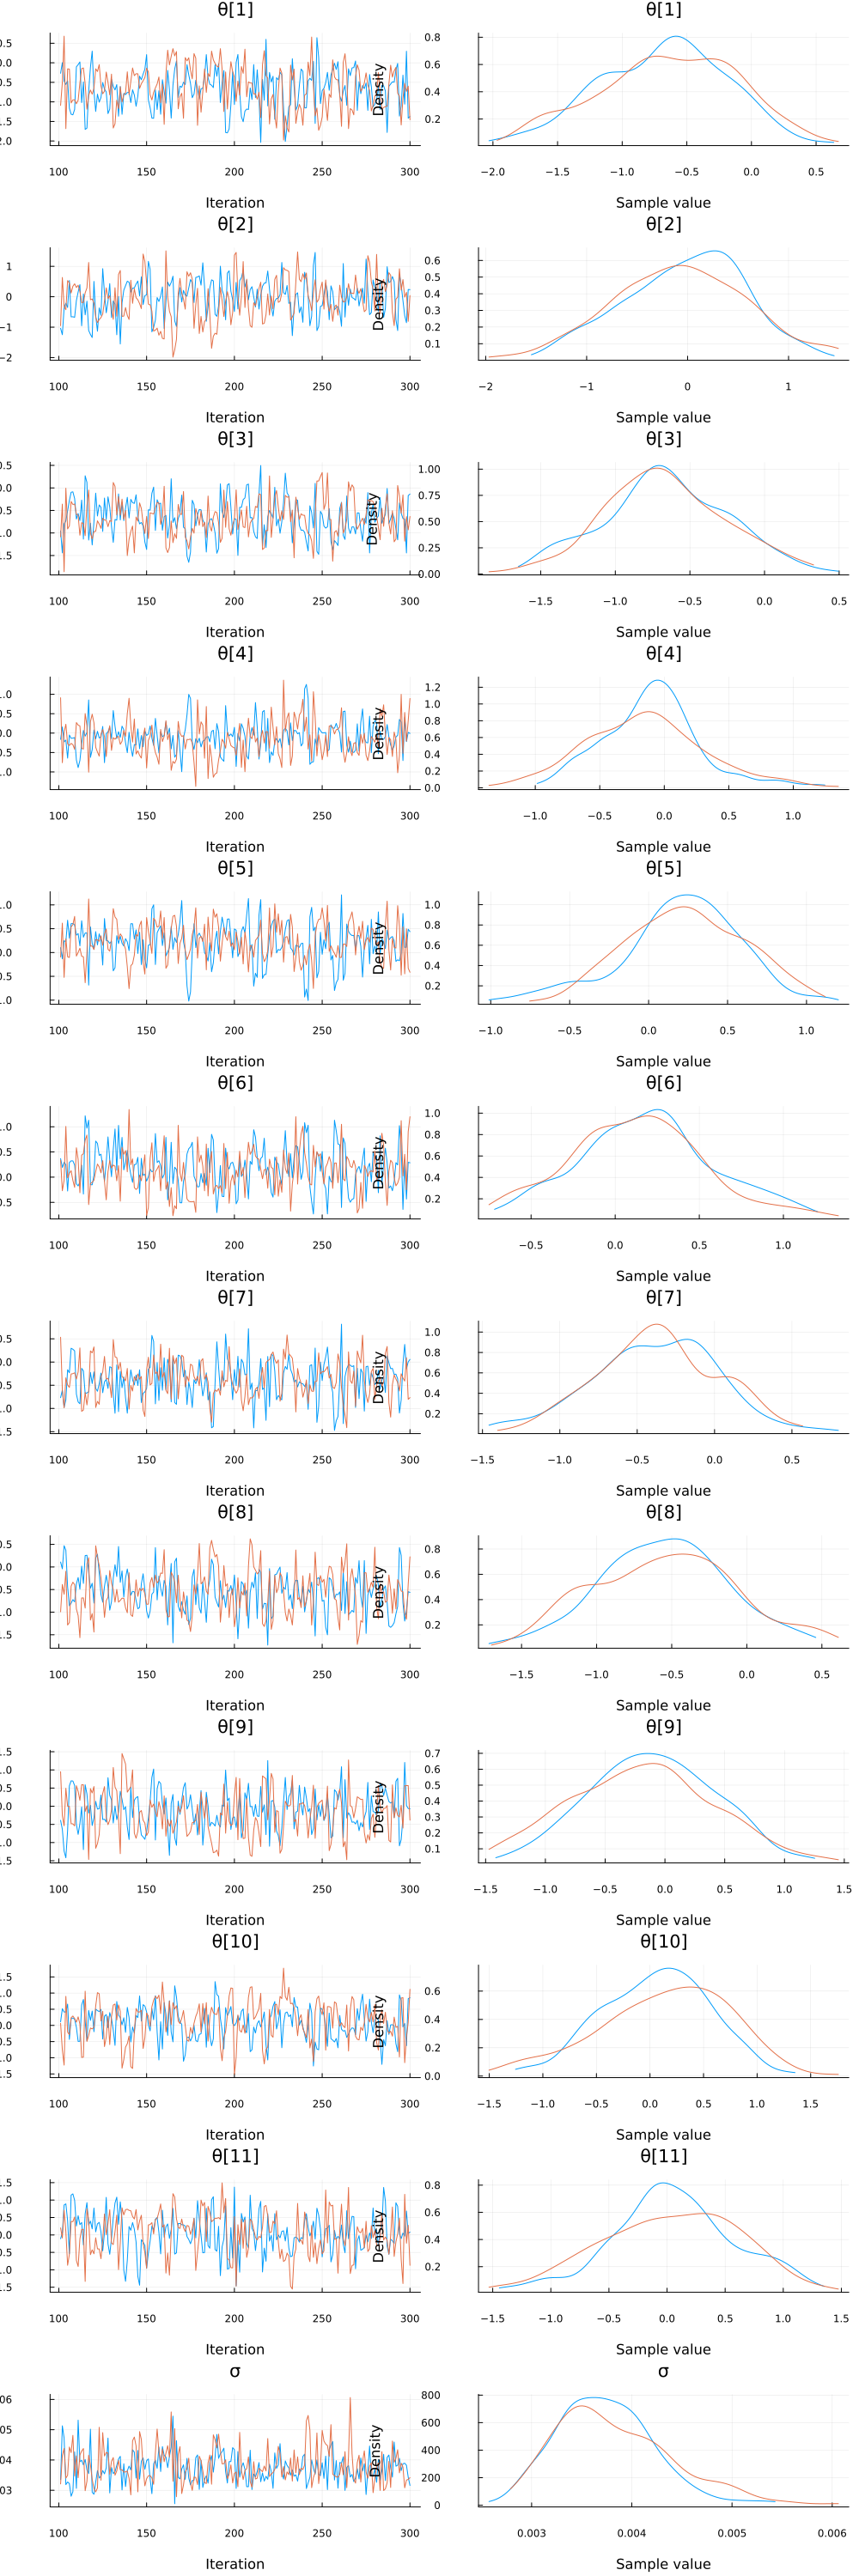

In [7]:
mcmc_chain = MCMCChains.Chains(chain)
MCMCChains.describe(mcmc_chain)
plot(mcmc_chain)


## Recover posterior samples of $\beta(t)$

The next cell extracts posterior samples of the last-layer weights and turns them into uncertainty bands for $\beta(t)$.


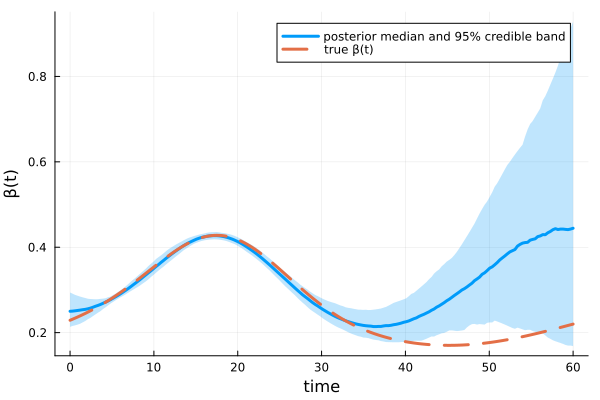

In [8]:
θ_symbols = [Symbol("θ[$j]") for j in 1:n_features]
θ_draws = reduce(hcat, [vec(Array(mcmc_chain[:, s, :])) for s in θ_symbols])

t_grid = collect(range(tspan[1], tspan[2]; length=200))
β_draws = [
    β_last_layer(t, collect(θ_draws[i, :]))
    for i in axes(θ_draws, 1), t in t_grid
]

β_q = reduce(hcat, [quantile(β_draws[:, j], [0.025, 0.50, 0.975]) for j in axes(β_draws, 2)])

plot(
    t_grid,
    β_q[2, :];
    ribbon=(β_q[2, :] .- β_q[1, :], β_q[3, :] .- β_q[2, :]),
    label="posterior median and 95% credible band",
    xlabel="time",
    ylabel="β(t)",
    linewidth=3,
    fillalpha=0.25
)
plot!(t_grid, β_true.(t_grid); label="true β(t)", linewidth=3, linestyle=:dash)


## Posterior predictive uncertainty for the infected compartment

Sampling $\theta$ gives a distribution over SIR trajectories, not only a distribution over $\beta(t)$.


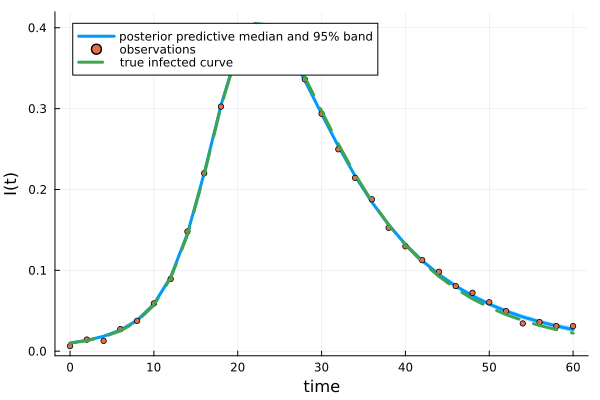

In [9]:
n_keep = min(200, size(θ_draws, 1))
keep = randperm(size(θ_draws, 1))[1:n_keep]
I_draws = permutedims(reduce(hcat, [predict_I(collect(θ_draws[i, :]); saveat=t_obs) for i in keep]))
I_q = reduce(hcat, [quantile(I_draws[:, j], [0.025, 0.50, 0.975]) for j in axes(I_draws, 2)])

plot(
    t_obs,
    I_q[2, :];
    ribbon=(I_q[2, :] .- I_q[1, :], I_q[3, :] .- I_q[2, :]),
    label="posterior predictive median and 95% band",
    xlabel="time",
    ylabel="I(t)",
    linewidth=3,
    fillalpha=0.25,
    legend=:topleft
)
scatter!(t_obs, I_obs; label="observations", markersize=3)
plot!(t_obs, I_clean; label="true infected curve", linewidth=3, linestyle=:dash)


## What to remember

- The mechanistic SIR equations constrain the posterior predictive trajectories.
- The Bayesian last layer gives uncertainty in the learned time-varying transmission rate.
- Sampling only the last layer is a pragmatic compromise: it is much cheaper than full Bayesian neural ODE inference, but more informative than a single point estimate.
- The same pattern can be reused with pretrained neural features, richer observation models, or real epidemic incidence data.
